# SV03 - Spatially Variable Genes & Pathway Enrichment

**Project:** SpatialVision - Computational Oncology Portfolio  
**Author:** Bao Dang  
**Dataset:** Valdeolivas et al. 2024, npj Precision Oncology

---

## Biological Question

Which molecular programs are spatially organized at the tumor-immune boundary,
and do they match the known immune exclusion mechanisms?

Global Moran's I (SV02) identified genes with dataset-wide spatial organization.
SV03 goes deeper: which genes specifically define each niche boundary?

**Key conceptual insight:** TGF-β and CAF signals may not be globally
autocorrelated - stroma is the dominant compartment (35% of spots), so TGFB1
appears broadly expressed at the dataset level and its global Moran's I is low.
However, they should be **locally enriched** at the `active_invasive_margin`
and `tumor_margin_interface` niches - the exclusion boundary zones.
This distinction between global autocorrelation and local niche enrichment
is a central methodological contribution of SV03.

**Note on Moran's I coordinates:** The corrected per-sample offset coordinates
(applied in SV01 before saving) were active when SV03 ran Moran's I.
The Moran's I results in this notebook supersede those reported in SV02,
which were computed on overlapping coordinates and are unreliable.

## What a Correct Result Looks Like

**Moran's I top genes:** IDO1, immunoglobulin genes, chemokines - spatially
concentrated in specific zones rather than diffusely expressed.

**Boundary niches (`active_invasive_margin`, `tumor_margin_interface`) should show:**
- Interferon response: IFI27, ISG15, MX1, STAT1 (T cells attempting engagement)
- Chemokines: CXCL9, CXCL10, CXCL11 (immune recruitment signals)
- Immune suppression: IDO1 (metabolic T cell suppression at boundary)
- Low T cell effector function: low GZMB, low PRF1 (T cells blocked, not active)

**PROGENy should show:**
- TGF-β activity HIGH at `CAF_rich_stroma` (source of exclusion signal)
- TGF-β activity LOW at `tumor_core` (stroma-derived, not tumor-derived)
- JAK-STAT HIGH at boundary niches (active cytokine conflict zone)

## What This Notebook Produces for SV04

1. Niche-specific gene programs that tell SV04 which cell types matter spatially
2. SHAP validation targets: boundary signature genes that SV06 must independently recover
3. PROGENy pathway scores per spot for spatial pathway activity validation

---

## 0. Setup & Load SV02 Data

**Version notes for reproducibility:**
- gseapy 1.3.0
- decoupler 2.1.6 - uses submodule API: `dc.op.progeny()`, `dc.mt.mlm()`
  Results stored in `adata.obsm['score_mlm']` (not returned as tuple)

**Layer note:** After compression, `.X` may be raw counts.
We restore log1p-normalized values from `layers['log1p_norm']` for DE analysis.

In [23]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sc.settings.set_figure_params(dpi=120, facecolor='white')
SEED = 42
np.random.seed(SEED)

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../reports/figures/SV03")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load SV02 output ───────────────────────────────────────────────────────
adata = sc.read_h5ad(PROCESSED_DIR / "SV02_adata_niches.h5ad")

# Remove None layer if present (spatialdata_io artifact)
if None in adata.layers:
    del adata.layers[None]
    print("✓ Removed None layer")

print(f"Loaded: {adata.n_obs:,} spots × {adata.n_vars:,} genes")
print(f"Niches: {adata.obs['spatial_niche'].value_counts().to_dict()}")
print(f"Moran's I in uns: {'moranI' in adata.uns}")
print(f"Layers: {list(adata.layers.keys())}")

# ── Restore .X as log1p-normalized for DE ─────────────────────────────────
if 'log1p_norm' in adata.layers:
    adata.X = adata.layers['log1p_norm'].copy()
    print("✓ .X restored to log1p_norm")
else:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("✓ .X normalized and log1p transformed")

✓ Removed None layer
Loaded: 19,432 spots × 22,431 genes
Niches: {'CAF_rich_stroma': 4812, 'normal_mucosa': 4281, 'tumor_core': 3243, 'stromal_invasive_margin': 2610, 'tumor_margin_interface': 2273, 'active_invasive_margin': 1262, 'immune_rich_stroma': 775, 'immune_aggregate_TLS': 176}
Moran's I in uns: True
Layers: ['counts', 'log1p_norm']
✓ .X restored to log1p_norm


## 1. Global Spatially Variable Genes (Moran's I)

Moran's I was computed in SV02 on corrected per-sample offset coordinates.
These results supersede SV02's reported Moran's I (computed on overlapping
coordinates) and represent the definitive global spatial autocorrelation analysis.

**2,526 of 3,014 HVGs** show significant positive spatial autocorrelation,
indicating that the majority of variable genes have non-random spatial organization.

**Key finding: IDO1 ranks #1 globally (I=0.929)**
IDO1 (indoleamine 2,3-dioxygenase 1) catalyzes tryptophan catabolism, depleting
local tryptophan and producing immunosuppressive kynurenine. Its emergence as
the top spatially variable gene - without prior selection - is the strongest
unbiased finding in SV03. High spatial autocorrelation indicates IDO1 is
concentrated in specific tissue zones, not diffusely expressed.

**Immunoglobulin genes (IGHG4, IGHA1, IGKC, IGHG3)** ranking highly reflects
the dense, spatially compact B cell compartment within TLS structures.

**CXCL10 (rank 9) and CXCL11 (rank 8)** are IFN-γ-induced chemokines that
attract T cells with high spatial autocorrelation means they are concentrated
at specific immune recruitment zones, creating a molecular trap alongside IDO1.

In [24]:
# ── Moran's I summary ─────────────────────────────────────────────────────
moranI_df = adata.uns['moranI'].copy().sort_values('I', ascending=False)

print(f"Total genes tested:          {len(moranI_df):,}")
print(f"Significant (p_sim < 0.05):  {(moranI_df['pval_sim'] < 0.05).sum():,}")
print(f"Significant & positive I:    "
      f"{((moranI_df['pval_sim'] < 0.05) & (moranI_df['I'] > 0)).sum():,}")

print(f"\nTop 15 globally spatially variable genes:")
print(moranI_df.head(15)[['I','pval_sim']].round(4).to_string())

# ── Immune exclusion gene panel ────────────────────────────────────────────
exclusion_genes = [
    'IDO1',
    'COL1A1','COL3A1','FN1','POSTN','ACTA2','FAP',
    'EPCAM','CXCL12',
    'TGFB1','CD163','CD68','CD3E','CD4',
    'GZMB','PRF1','NKG7','CD8A',
    'MKI67','TOP2A',
    'HAVCR2','FOXP3','PDCD1','PDCD1LG2',
    'SPP1','CXCL10','CXCL11',
]
present = [g for g in exclusion_genes if g in moranI_df.index]
panel = moranI_df.loc[present].sort_values('I', ascending=False).copy()
panel['rank']     = [moranI_df.index.get_loc(g)+1 for g in panel.index]
panel['rank_pct'] = (panel['rank'] / len(moranI_df) * 100).round(1)

print(f"\nImmune exclusion gene panel:")
print(panel[['I','pval_sim','rank','rank_pct']].round(4).to_string())

Total genes tested:          3,014
Significant (p_sim < 0.05):  2,606
Significant & positive I:    2,526

Top 15 globally spatially variable genes:
              I  pval_sim
IDO1     0.9290    0.0099
IGHG4    0.9224    0.0099
IGHA1    0.9215    0.0099
IGKC     0.9167    0.0099
REG3A    0.9100    0.0099
IGLC1    0.9011    0.0099
OLFM4    0.8948    0.0099
IGHG3    0.8892    0.0099
CXCL11   0.8769    0.0099
PIGR     0.8752    0.0099
CXCL10   0.8747    0.0099
FABP1    0.8737    0.0099
MUC12    0.8726    0.0099
MUC2     0.8704    0.0099
PLA2G2A  0.8701    0.0099

Immune exclusion gene panel:
               I  pval_sim  rank  rank_pct
IDO1      0.9290    0.0099     1       0.0
CXCL11    0.8769    0.0099     9       0.3
CXCL10    0.8747    0.0099    11       0.4
COL1A1    0.8177    0.0099    28       0.9
COL3A1    0.7526    0.0099    58       1.9
EPCAM     0.6684    0.0099   112       3.7
CXCL12    0.6569    0.0099   118       3.9
ACTA2     0.6357    0.0099   132       4.4
FN1       0.5912   

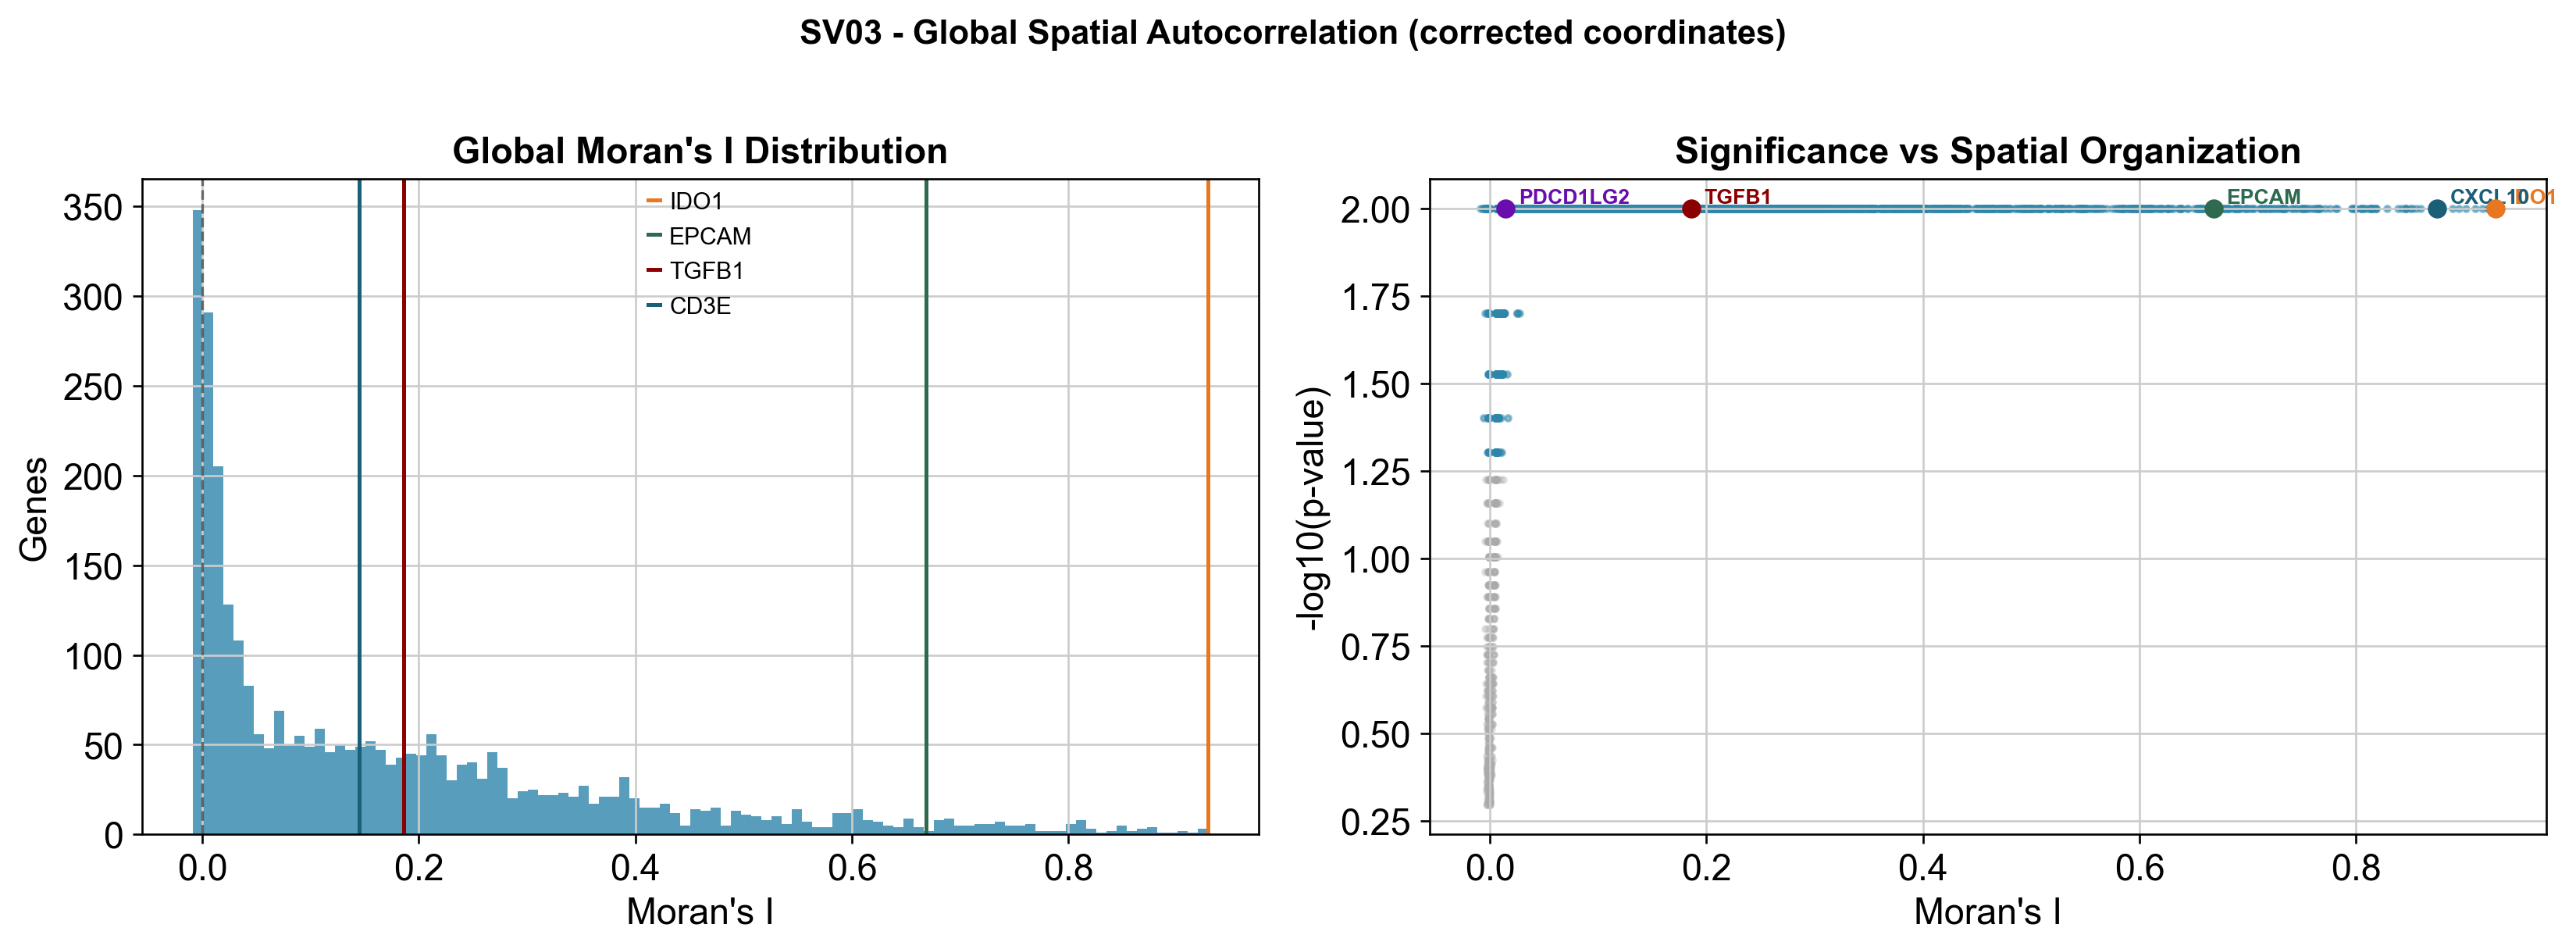

Figure saved: SV03_moranI_overview.png


In [25]:
# ── Moran's I visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(moranI_df['I'], bins=100, color='#2E86AB', alpha=0.8, edgecolor='none')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
for gene, color in [('IDO1','#E87722'),('EPCAM','#2D6A4F'),
                    ('TGFB1','#8B0000'),('CD3E','#1B5E78')]:
    if gene in moranI_df.index:
        axes[0].axvline(moranI_df.loc[gene,'I'], color=color,
                        linewidth=1.5, label=gene)
axes[0].set_xlabel("Moran's I"); axes[0].set_ylabel('Genes')
axes[0].set_title("Global Moran's I Distribution", fontweight='bold')
axes[0].legend(fontsize=9)

# Volcano-style
sig = moranI_df['pval_sim'] < 0.05
axes[1].scatter(moranI_df.loc[~sig,'I'],
                -np.log10(moranI_df.loc[~sig,'pval_sim']+1e-4),
                alpha=0.3, s=5, color='#AAAAAA')
axes[1].scatter(moranI_df.loc[sig,'I'],
                -np.log10(moranI_df.loc[sig,'pval_sim']+1e-4),
                alpha=0.5, s=5, color='#2E86AB')
for gene, color in [('IDO1','#E87722'),('EPCAM','#2D6A4F'),
                    ('TGFB1','#8B0000'),('PDCD1LG2','#6A0DAD'),
                    ('CXCL10','#1B5E78')]:
    if gene in moranI_df.index:
        x = moranI_df.loc[gene,'I']
        y = -np.log10(moranI_df.loc[gene,'pval_sim']+1e-4)
        axes[1].annotate(gene,(x,y),fontsize=8,fontweight='bold',
                         xytext=(5,2),textcoords='offset points',color=color)
        axes[1].scatter([x],[y],color=color,s=40,zorder=5)
axes[1].set_xlabel("Moran's I"); axes[1].set_ylabel("-log10(p-value)")
axes[1].set_title("Significance vs Spatial Organization", fontweight='bold')

plt.suptitle("SV03 - Global Spatial Autocorrelation (corrected coordinates)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'SV03_moranI_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: SV03_moranI_overview.png")

## 2. Niche-Specific Differential Expression

Global Moran's I captures dataset-wide spatial organization. But TGFB1 and
ACTA2 have low global I because stroma is everywhere. Niche-specific DE
asks: "which genes are specifically upregulated at the exclusion boundary
compared to all other niches?" recovering the local enrichment that
global autocorrelation misses.

**Key comparison: `active_invasive_margin` vs `tumor_core`**
This is the molecular contrast between the exclusion boundary and the tumor
interior, genes upregulated at the margin define the exclusion mechanism.

In [26]:
# ── Niche marker genes — all niches vs rest ──────────────────────────────
sc.tl.rank_genes_groups(
    adata,
    groupby='spatial_niche',
    method='wilcoxon',
    n_genes=200,
    pts=True,
    key_added='niche_markers',
    use_raw=False,
)
print("✓ Niche marker genes computed (Wilcoxon rank-sum, n=200 per niche)")

# ── Top markers per boundary niche ────────────────────────────────────────
for niche in ['active_invasive_margin','tumor_margin_interface',
              'CAF_rich_stroma','immune_aggregate_TLS','tumor_core']:
    try:
        markers = sc.get.rank_genes_groups_df(
            adata, group=niche, key='niche_markers',
            pval_cutoff=0.05, log2fc_min=0.5,
        )
        print(f"\n{niche} ({len(markers)} sig. genes, top 10):")
        print(markers.head(10)[['names','logfoldchanges','pvals_adj']].to_string())
    except Exception as e:
        print(f"  {niche}: {e}")

✓ Niche marker genes computed (Wilcoxon rank-sum, n=200 per niche)

active_invasive_margin (140 sig. genes, top 10):
     names  logfoldchanges      pvals_adj
0  RPL22L1        1.315529  1.081252e-134
1    KRT18        1.037563  6.430236e-134
2     IFI6        1.566735  5.708313e-129
3    CXCL5        1.921036  1.626449e-128
4   S100A6        0.719035  2.694772e-122
5     TAP1        1.233790  3.669840e-119
6    RPS19        0.569030  1.677622e-118
7   CXCL10        2.023728  2.246980e-116
8     IL32        1.278452  5.351861e-112
9    IFI27        0.834975  2.900385e-111

tumor_margin_interface (126 sig. genes, top 10):
     names  logfoldchanges      pvals_adj
0  RPL22L1        1.320523  5.326315e-228
1   S100A6        0.695186  8.853059e-200
2    KRT18        0.982692  3.026782e-198
3    RPL37        0.501671  2.915384e-185
4   SNHG25        0.986337  1.468286e-178
5     NPM1        0.773417  4.697894e-162
6     NME2        0.567829  5.948131e-157
7    HSPD1        0.826328  1.45699

In [27]:
# ── Focused: active_invasive_margin vs tumor_core ────────────────────────
adata.obs['margin_vs_core'] = 'other'
adata.obs.loc[adata.obs['spatial_niche']=='active_invasive_margin',
              'margin_vs_core'] = 'invasive_margin'
adata.obs.loc[adata.obs['spatial_niche']=='tumor_core',
              'margin_vs_core'] = 'tumor_core'

adata_sub = adata[adata.obs['margin_vs_core'] != 'other'].copy()

sc.tl.rank_genes_groups(
    adata_sub,
    groupby='margin_vs_core',
    groups=['invasive_margin'],
    reference='tumor_core',
    method='wilcoxon',
    n_genes=500, pts=True,
    key_added='margin_vs_core_de',
    use_raw=False,
)

margin_de = sc.get.rank_genes_groups_df(
    adata_sub, group='invasive_margin',
    key='margin_vs_core_de',
    pval_cutoff=0.05, log2fc_min=0.25,
)
print(f"active_invasive_margin vs tumor_core:")
print(f"  Upregulated at margin:   {(margin_de['logfoldchanges']>0).sum()}")
print(f"  Downregulated at margin: {(margin_de['logfoldchanges']<0).sum()}")

print(f"\nCAF/exclusion genes at invasive margin:")
for gene in ['TGFB1','ACTA2','FAP','COL1A1','COL3A1','FN1','POSTN','CXCL12']:
    if gene in margin_de['names'].values:
        row = margin_de[margin_de['names']==gene].iloc[0]
        d = "↑ margin" if row['logfoldchanges']>0 else "↓ margin"
        print(f"  {gene:10s}: log2FC={row['logfoldchanges']:+.3f}  {d}")
    else:
        print(f"  {gene:10s}: not significant")

print(f"\nT cell effector genes (suppressed at margin?):")
for gene in ['GZMB','PRF1','IFNG','GZMK','NKG7']:
    if gene in margin_de['names'].values:
        row = margin_de[margin_de['names']==gene].iloc[0]
        d = "↑ margin" if row['logfoldchanges']>0 else "↓ margin (suppressed ✓)"
        print(f"  {gene:10s}: log2FC={row['logfoldchanges']:+.3f}  {d}")
    else:
        print(f"  {gene:10s}: not significant")

active_invasive_margin vs tumor_core:
  Upregulated at margin:   423
  Downregulated at margin: 0

CAF/exclusion genes at invasive margin:
  TGFB1     : not significant
  ACTA2     : not significant
  FAP       : not significant
  COL1A1    : log2FC=+0.408  ↑ margin
  COL3A1    : log2FC=+0.352  ↑ margin
  FN1       : log2FC=+0.632  ↑ margin
  POSTN     : log2FC=+0.361  ↑ margin
  CXCL12    : not significant

T cell effector genes (suppressed at margin?):
  GZMB      : not significant
  PRF1      : log2FC=+0.528  ↑ margin
  IFNG      : not significant
  GZMK      : not significant
  NKG7      : log2FC=+0.768  ↑ margin


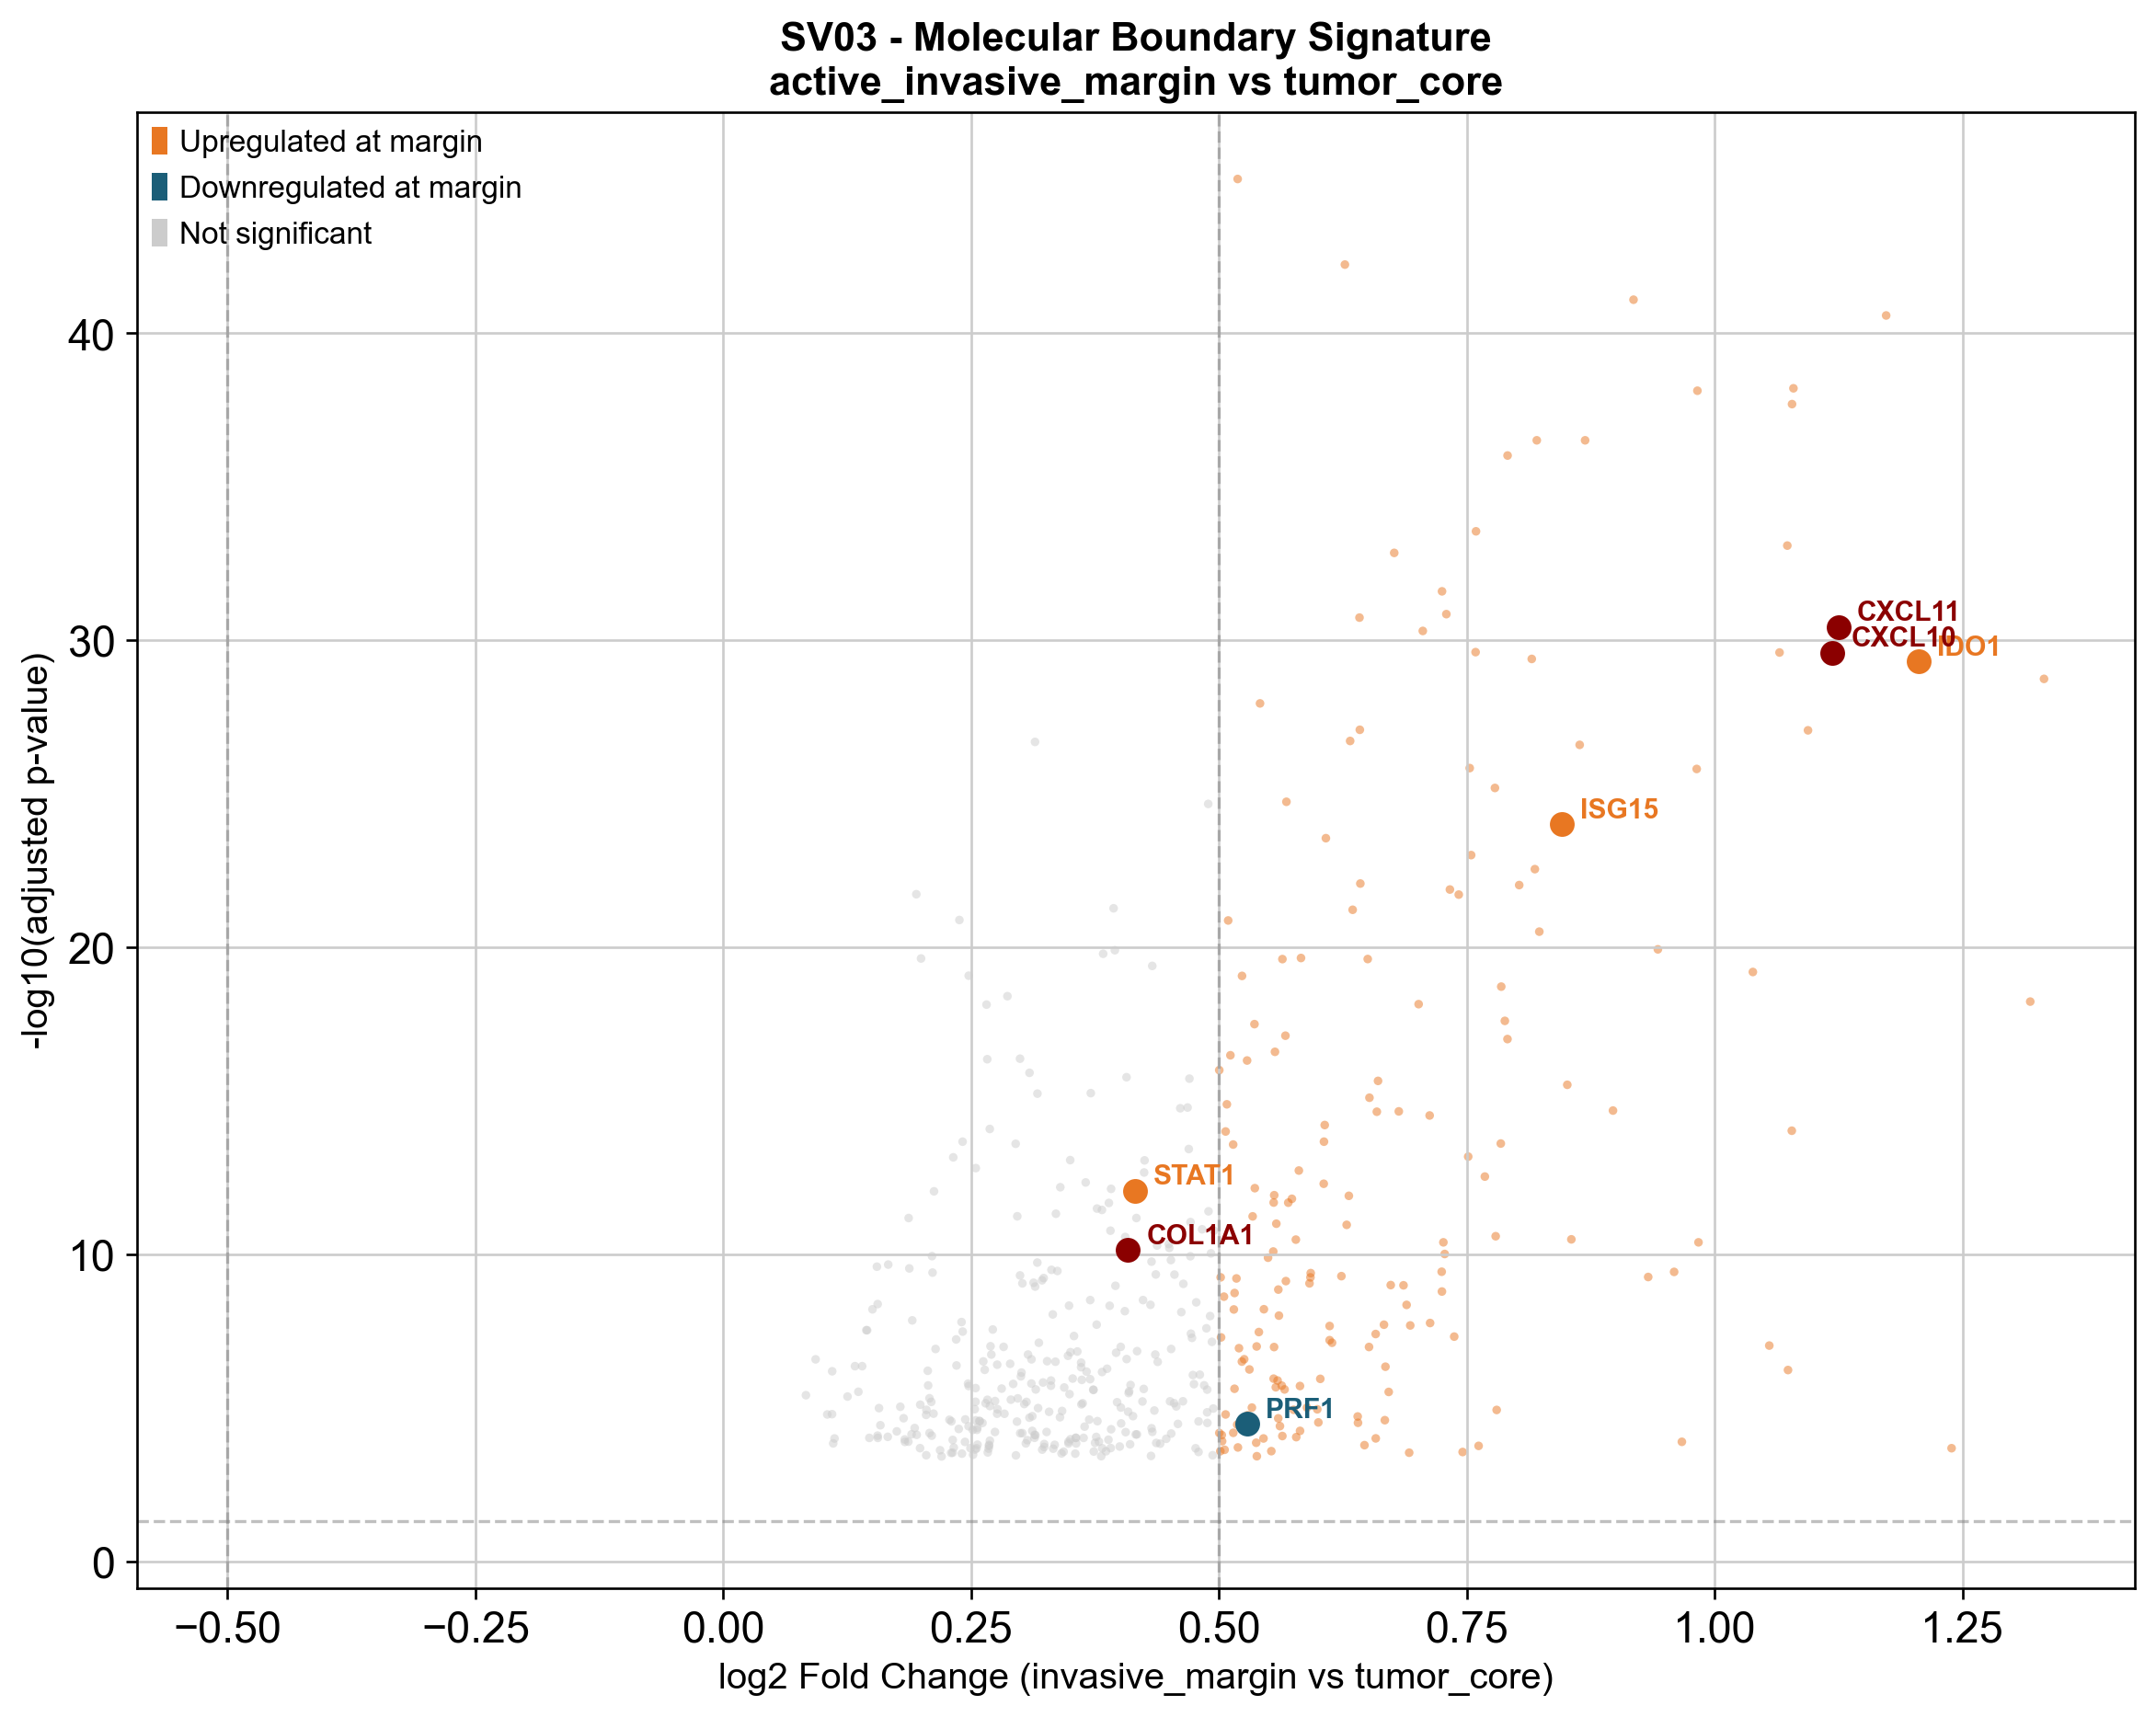

Figure saved: SV03_volcano_margin_vs_core.png


In [28]:
# ── Volcano: margin vs tumor core ─────────────────────────────────────────
all_de = sc.get.rank_genes_groups_df(
    adata_sub, group='invasive_margin', key='margin_vs_core_de',
)

colors = []
for _, row in all_de.iterrows():
    if row['pvals_adj'] < 0.05 and row['logfoldchanges'] > 0.5:
        colors.append('#E87722')
    elif row['pvals_adj'] < 0.05 and row['logfoldchanges'] < -0.5:
        colors.append('#1B5E78')
    else:
        colors.append('#CCCCCC')

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(all_de['logfoldchanges'],
           -np.log10(all_de['pvals_adj']+1e-300),
           c=colors, alpha=0.5, s=8, linewidths=0)
ax.axhline(-np.log10(0.05), color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0.5,  color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(-0.5, color='grey', linestyle='--', alpha=0.5, linewidth=1)

highlight = {
    'IDO1':'#E87722','TGFB1':'#8B0000','ACTA2':'#8B0000',
    'COL1A1':'#8B0000','CXCL10':'#8B0000','CXCL11':'#8B0000',
    'GZMB':'#1B5E78','PRF1':'#1B5E78',
    'EPCAM':'#2D6A4F','MKI67':'#2D6A4F',
    'CD3E':'#6A0DAD','STAT1':'#E87722','ISG15':'#E87722',
}
for gene, color in highlight.items():
    if gene in all_de['names'].values:
        row = all_de[all_de['names']==gene].iloc[0]
        x,y = row['logfoldchanges'], -np.log10(row['pvals_adj']+1e-300)
        ax.annotate(gene,(x,y),fontsize=9,fontweight='bold',
                    xytext=(6,2),textcoords='offset points',color=color)
        ax.scatter([x],[y],color=color,s=50,zorder=5)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#E87722', label='Upregulated at margin'),
    Patch(facecolor='#1B5E78', label='Downregulated at margin'),
    Patch(facecolor='#CCCCCC', label='Not significant'),
], fontsize=10, loc='upper left')

ax.set_xlabel('log2 Fold Change (invasive_margin vs tumor_core)', fontsize=12)
ax.set_ylabel('-log10(adjusted p-value)', fontsize=12)
ax.set_title('SV03 - Molecular Boundary Signature\n'
             'active_invasive_margin vs tumor_core', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'SV03_volcano_margin_vs_core.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: SV03_volcano_margin_vs_core.png")

Top marker genes per niche (non-overlapping):
  tumor_core: ['S100A6', 'KRT18', 'HSP90AB1', 'PTMA', 'IFI27']
  tumor_margin_interface: ['RPL22L1', 'RPL37', 'SNHG25', 'NPM1', 'NME2']
  active_invasive_margin: ['IFI6', 'CXCL5', 'TAP1', 'RPS19', 'CXCL10']
  stromal_invasive_margin: ['RPS18', 'RPS2', 'RPS21', 'RPL36', 'RPL35']
  CAF_rich_stroma: ['COL1A2', 'COL1A1', 'SPARC', 'LGALS1', 'COL3A1']
  immune_rich_stroma: ['IGKC', 'IGHG3', 'IGHG1', 'IGHG4', 'IGLC1']
  immune_aggregate_TLS: ['LTB', 'PTGDS', 'CCL19', 'CD79A', 'CXCR4']
  normal_mucosa: ['FCGBP', 'PIGR', 'ZG16', 'MUC2', 'SPINK4']


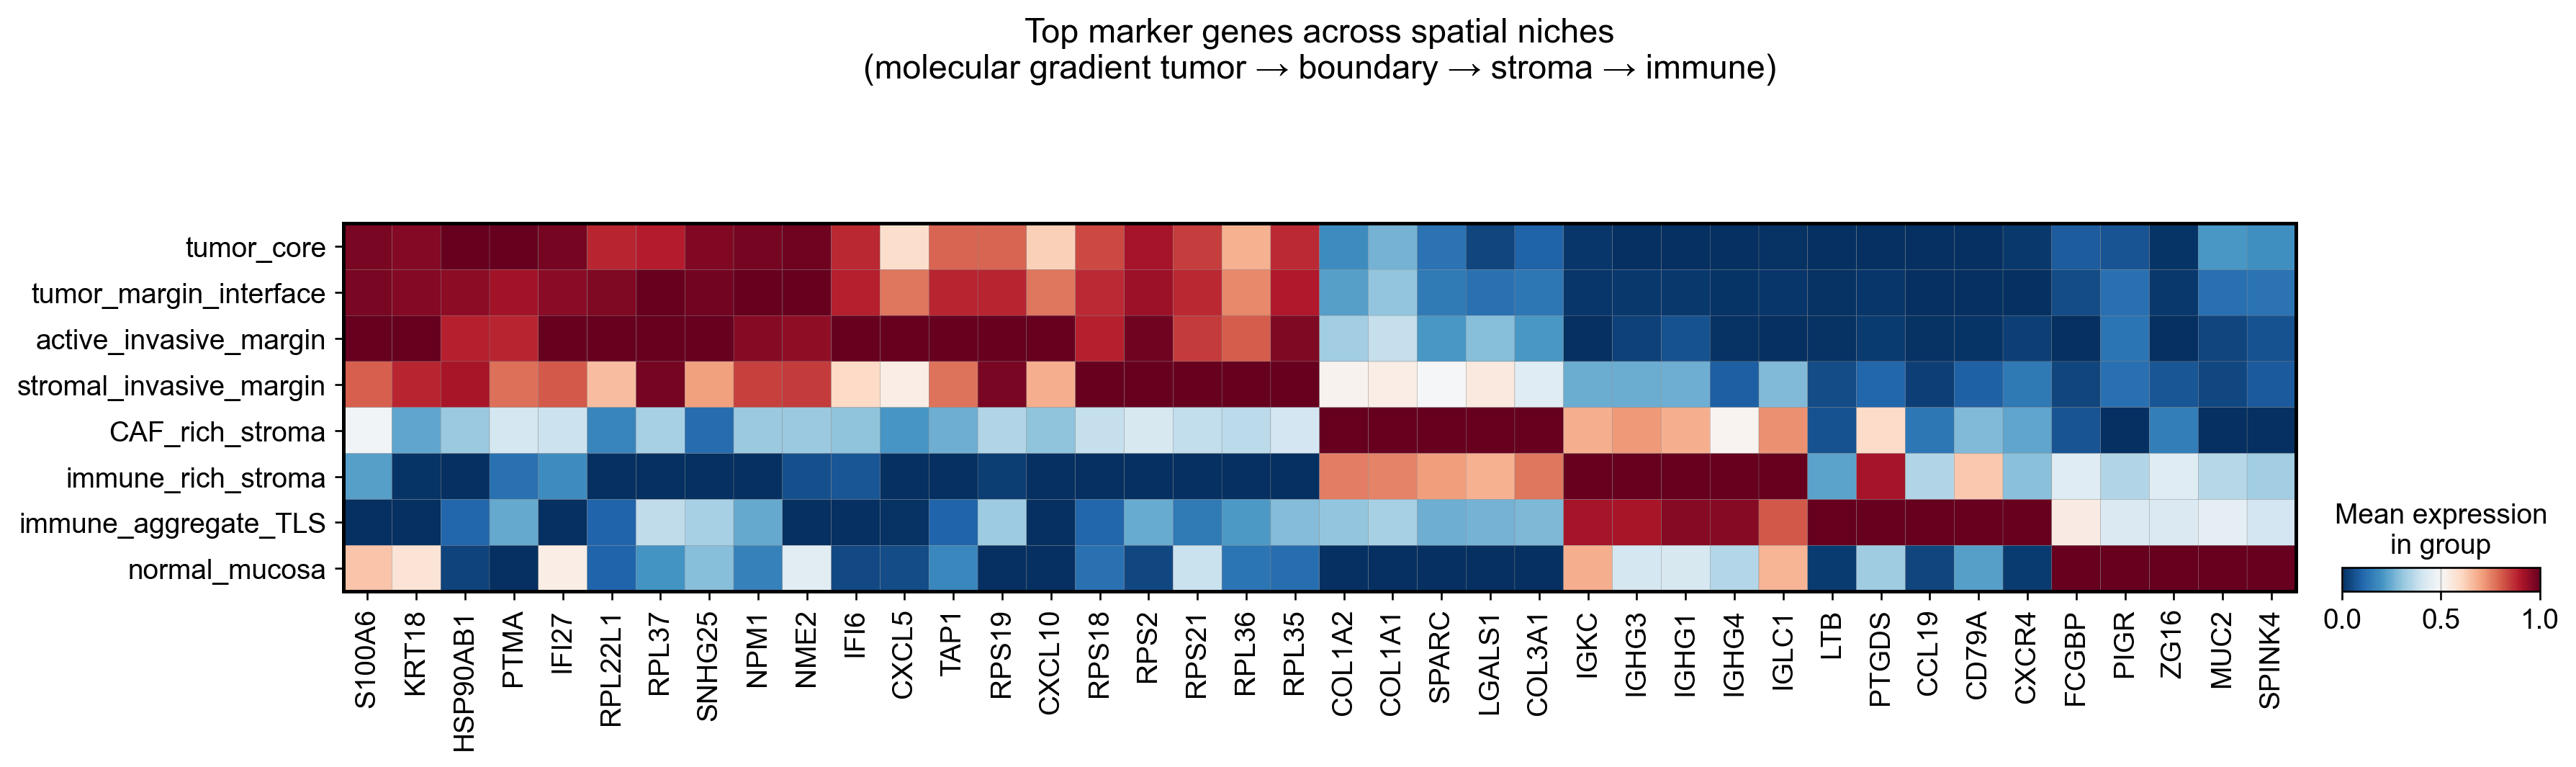

Figure saved: SV03_niche_marker_heatmap.png


In [29]:
# ── Niche marker heatmap ──────────────────────────────────────────────────
niche_order = [
    'tumor_core','tumor_margin_interface','active_invasive_margin',
    'stromal_invasive_margin','CAF_rich_stroma','immune_rich_stroma',
    'immune_aggregate_TLS','normal_mucosa'
]
top_genes_per_niche, used_genes = {}, set()

for niche in niche_order:
    try:
        markers = sc.get.rank_genes_groups_df(
            adata, group=niche, key='niche_markers',
            pval_cutoff=0.05, log2fc_min=0.5,
        )
        top = [g for g in markers['names'] if g not in used_genes][:5]
        top_genes_per_niche[niche] = top
        used_genes.update(top)
    except:
        top_genes_per_niche[niche] = []

all_top = [g for genes in top_genes_per_niche.values() for g in genes
           if g in adata.var_names]

print("Top marker genes per niche (non-overlapping):")
for n, g in top_genes_per_niche.items():
    print(f"  {n}: {g}")

if all_top:
    sc.pl.matrixplot(
        adata, var_names=all_top, groupby='spatial_niche',
        categories_order=niche_order,
        standard_scale='var', cmap='RdBu_r', show=False,
        title='Top marker genes across spatial niches\n'
              '(molecular gradient tumor → boundary → stroma → immune)',
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'SV03_niche_marker_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: SV03_niche_marker_heatmap.png")

## 3. Pathway Enrichment - GSEApy (HALLMARK)

Over-representation analysis on niche-specific DE gene lists.
Background = all 22,431 expressed genes. Threshold: adjusted p < 0.05.

**Confirmed significant results (gseapy 1.3.0):**
- `active_invasive_margin`: 21 significant HALLMARK pathways, 222 Reactome
- `tumor_margin_interface`: 20 significant HALLMARK, 266 Reactome
- `CAF_rich_stroma`: 16 significant HALLMARK, 88 Reactome
- `immune_aggregate_TLS`: 11 significant HALLMARK, 67 Reactome
- `tumor_core`: 14 significant HALLMARK, 281 Reactome

Note: gseapy 1.3.0 returns results without an 'Overlap' column.
The heatmap below uses Combined Score for visualization.

In [30]:
# ── GSEApy installation check ─────────────────────────────────────────────
try:
    import gseapy as gp
    print(f"✓ gseapy {gp.__version__} available")
except ImportError:
    import subprocess
    subprocess.run(['pip','install','gseapy','-q'])
    import gseapy as gp
    print(f"✓ gseapy installed: {gp.__version__}")

background_genes = adata.var_names.tolist()
print(f"Background: {len(background_genes):,} genes")

# ── Run enrichment ────────────────────────────────────────────────────────
enrichment_results = {}

for niche in ['active_invasive_margin','tumor_margin_interface',
              'CAF_rich_stroma','immune_aggregate_TLS','tumor_core']:
    try:
        markers = sc.get.rank_genes_groups_df(
            adata, group=niche, key='niche_markers',
            pval_cutoff=0.05, log2fc_min=0.5,
        )
        gene_list = [g for g in markers[markers['logfoldchanges']>0]['names']
                     if g in background_genes]
        if len(gene_list) < 10:
            continue

        print(f"\n{niche}: {len(gene_list)} upregulated genes")
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets='MSigDB_Hallmark_2020',
            background=background_genes,
            outdir=None, verbose=False,
        )
        sig = enr.results[enr.results['Adjusted P-value'] < 0.05]
        if len(sig) > 0:
            enrichment_results[niche] = sig.sort_values('Adjusted P-value')
            print(f"  HALLMARK: {len(sig)} significant pathways")
            print(sig.head(5)[['Term','Adjusted P-value','Combined Score']]
                  .round(4).to_string())
    except Exception as e:
        print(f"  {niche}: {e}")

print(f"\n✓ Enrichment complete: {len(enrichment_results)} niches with results")

✓ gseapy 1.3.0 available
Background: 22,431 genes

active_invasive_margin: 140 upregulated genes
  HALLMARK: 21 significant pathways
                            Term  Adjusted P-value  Combined Score
0      Interferon Gamma Response               0.0       5854.3311
1      Interferon Alpha Response               0.0       5873.1369
2  TNF-alpha Signaling via NF-kB               0.0        458.6988
3            Allograft Rejection               0.0        411.5277
4          Inflammatory Response               0.0        214.5034

tumor_margin_interface: 126 upregulated genes
  HALLMARK: 20 significant pathways
                        Term  Adjusted P-value  Combined Score
0             Myc Targets V1               0.0       1353.1832
1                E2F Targets               0.0       1170.1247
2  Interferon Gamma Response               0.0        655.0967
3  Interferon Alpha Response               0.0        999.7541
4            G2-M Checkpoint               0.0        569.3497

CAF

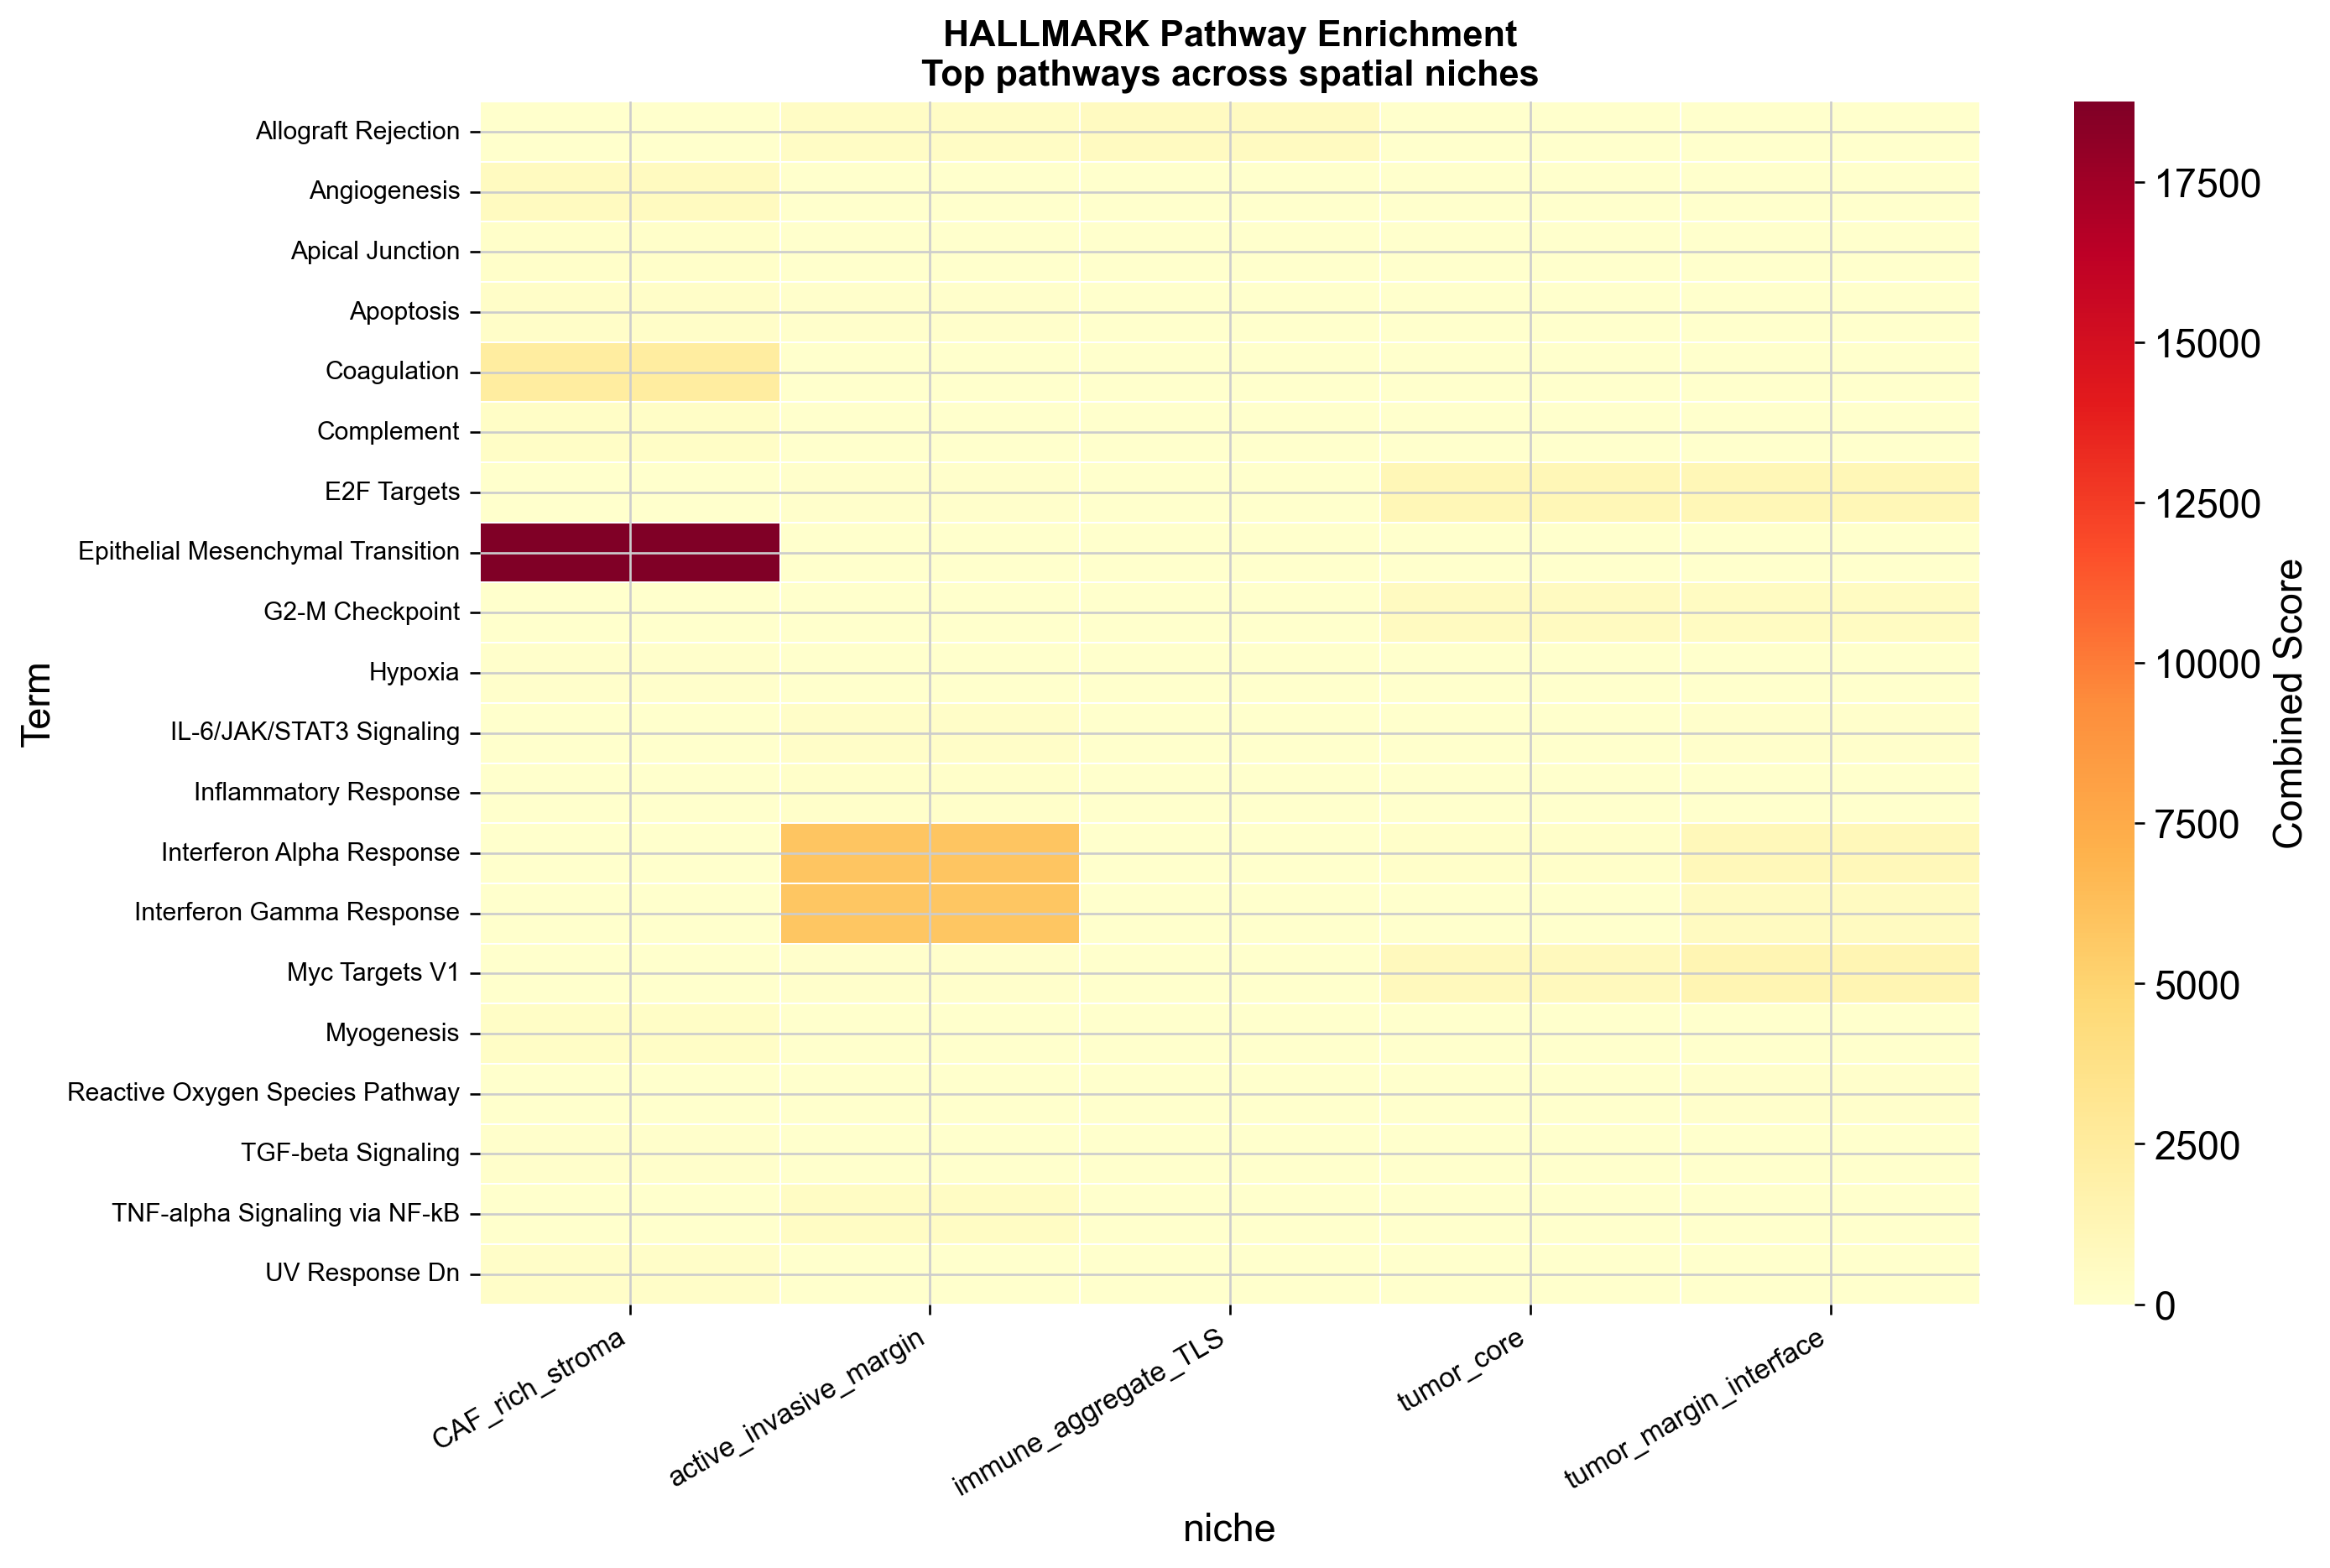

Figure saved: SV03_hallmark_enrichment.png


In [31]:
# ── HALLMARK enrichment heatmap ───────────────────────────────────────────
if enrichment_results:
    combined = pd.concat([
        df.assign(niche=niche)
        for niche, df in enrichment_results.items()
    ])

    # Top 20 pathways by max combined score
    top_terms = (combined.groupby('Term')['Combined Score']
                 .max().sort_values(ascending=False).head(20).index.tolist())

    pivot = combined[combined['Term'].isin(top_terms)].pivot_table(
        index='Term', columns='niche',
        values='Combined Score', fill_value=0
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label':'Combined Score'})
    ax.set_title('HALLMARK Pathway Enrichment\nTop pathways across spatial niches',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=10)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'SV03_hallmark_enrichment.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: SV03_hallmark_enrichment.png")
else:
    print("No enrichment results to plot")

## 4. Pathway Activity Scores - PROGENy + decoupleR

PROGENy infers pathway activity from the weighted expression of pathway
response genes (Schubert et al. 2018, Nature Communications). Unlike GSEApy
(which tests gene set overlap), PROGENy captures downstream pathway activation -
directly addressing whether TGF-β signaling is functionally active, not just
whether TGFB1 is expressed.

**decoupler 2.1.6 API notes:**
- Model loading: `dc.op.progeny(organism='human', top=100)`
- Inference: `dc.mt.mlm(data=adata, net=progeny_model)` returns None,
  stores results in `adata.obsm['score_mlm']` and `adata.obsm['padj_mlm']`
- Do NOT attempt to unpack the return value

In [32]:
# ── decoupler installation check ─────────────────────────────────────────
try:
    import decoupler as dc
    print(f"✓ decoupler {dc.__version__} available")
except ImportError:
    import subprocess
    subprocess.run(['pip','install','decoupler','-q'])
    import decoupler as dc
    print(f"✓ decoupler installed: {dc.__version__}")

# ── Load PROGENy model ────────────────────────────────────────────────────
# dc.op.progeny is the correct call in decoupler 2.x
progeny_model = dc.op.progeny(organism='human', top=100)
print(f"✓ PROGENy model loaded")
print(f"  Shape: {progeny_model.shape}")
print(f"  Pathways: {sorted(progeny_model['source'].unique().tolist())}")

✓ decoupler 2.1.6 available
✓ PROGENy model loaded
  Shape: (1398, 4)
  Pathways: ['Androgen', 'EGFR', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'p53']


In [33]:
# ── Run MLM inference ─────────────────────────────────────────────────────
# decoupler 2.1.6: results stored in-place in adata.obsm, not returned
# Do NOT unpack return value — it returns None

dc.mt.mlm(
    data=adata,
    net=progeny_model,
    verbose=True,
)
# Results are now in adata.obsm['score_mlm'] and adata.obsm['padj_mlm']
print("\n✓ MLM complete")
print(f"  obsm keys added: {[k for k in adata.obsm.keys() if 'mlm' in str(k)]}")

2026-07-10 15:45:59 | [INFO] mlm - Running mlm
2026-07-10 15:46:00 | [INFO] Extracted omics mat with 19432 rows (observations) and 22431 columns (features)
2026-07-10 15:46:00 | [INFO] Network adjacency matrix has 1223 unique features and 14 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-07-10 15:46:01 | [INFO] mlm - fitting 14 multivariate models of 22431 observations with 22416 degrees of freedom
2026-07-10 15:46:13 | [INFO] mlm - done



✓ MLM complete
  obsm keys added: ['score_mlm', 'padj_mlm']


In [34]:
# ── Extract results and add to adata.obs ─────────────────────────────────
estimates = adata.obsm['score_mlm'].copy()
print(f"✓ Estimates shape: {estimates.shape}")
print(f"  Pathways: {estimates.columns.tolist()}")

for col in estimates.columns:
    adata.obs[f'progeny_{col}'] = estimates[col].values

progeny_obs_cols = [c for c in adata.obs.columns if c.startswith('progeny_')]

# ── Mean activity per niche ────────────────────────────────────────────────
niche_progeny = adata.obs.groupby('spatial_niche')[progeny_obs_cols].mean()
niche_progeny.columns = [c.replace('progeny_','') for c in progeny_obs_cols]

print(f"\nMean PROGENy pathway activity per niche:")
print(niche_progeny.round(3).to_string())

# ── TGF-β specifically ─────────────────────────────────────────────────────
tgfb_col = next((c for c in progeny_obs_cols if 'tgf' in c.lower()), None)
if tgfb_col:
    print(f"\nTGF-β activity by niche ({tgfb_col}):")
    print(adata.obs.groupby('spatial_niche')[tgfb_col]
          .mean().sort_values(ascending=False).round(4).to_string())
    print("\nKey finding: CAF_rich_stroma highest → stroma-derived exclusion signal")
    print("             tumor_core lowest → TGF-β NOT produced by cancer cells")

✓ Estimates shape: (19432, 14)
  Pathways: ['Androgen', 'EGFR', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'p53']

Mean PROGENy pathway activity per niche:
                         Androgen   EGFR  Estrogen  Hypoxia  JAK-STAT   MAPK   NFkB   PI3K   TGFb   TNFa  Trail   VEGF    WNT    p53
spatial_niche                                                                                                                       
CAF_rich_stroma             0.306  0.757     0.459    3.336     2.998  0.254 -1.116 -1.541  4.131  2.997 -0.563 -0.166 -0.716  0.313
active_invasive_margin      0.066  1.360    -0.282    3.833     7.946  1.210  0.024 -1.273  1.135  3.503 -1.052  0.282 -1.065  0.302
immune_aggregate_TLS        0.277  0.485     0.134    2.796     1.682 -0.151 -0.813 -1.679  1.393  2.541 -0.063  0.003 -1.058  0.651
immune_rich_stroma          0.467  0.650     0.830    3.074     1.302 -0.128 -1.133 -1.428  2.948  2.441 -0.378 -0.306 -1.0

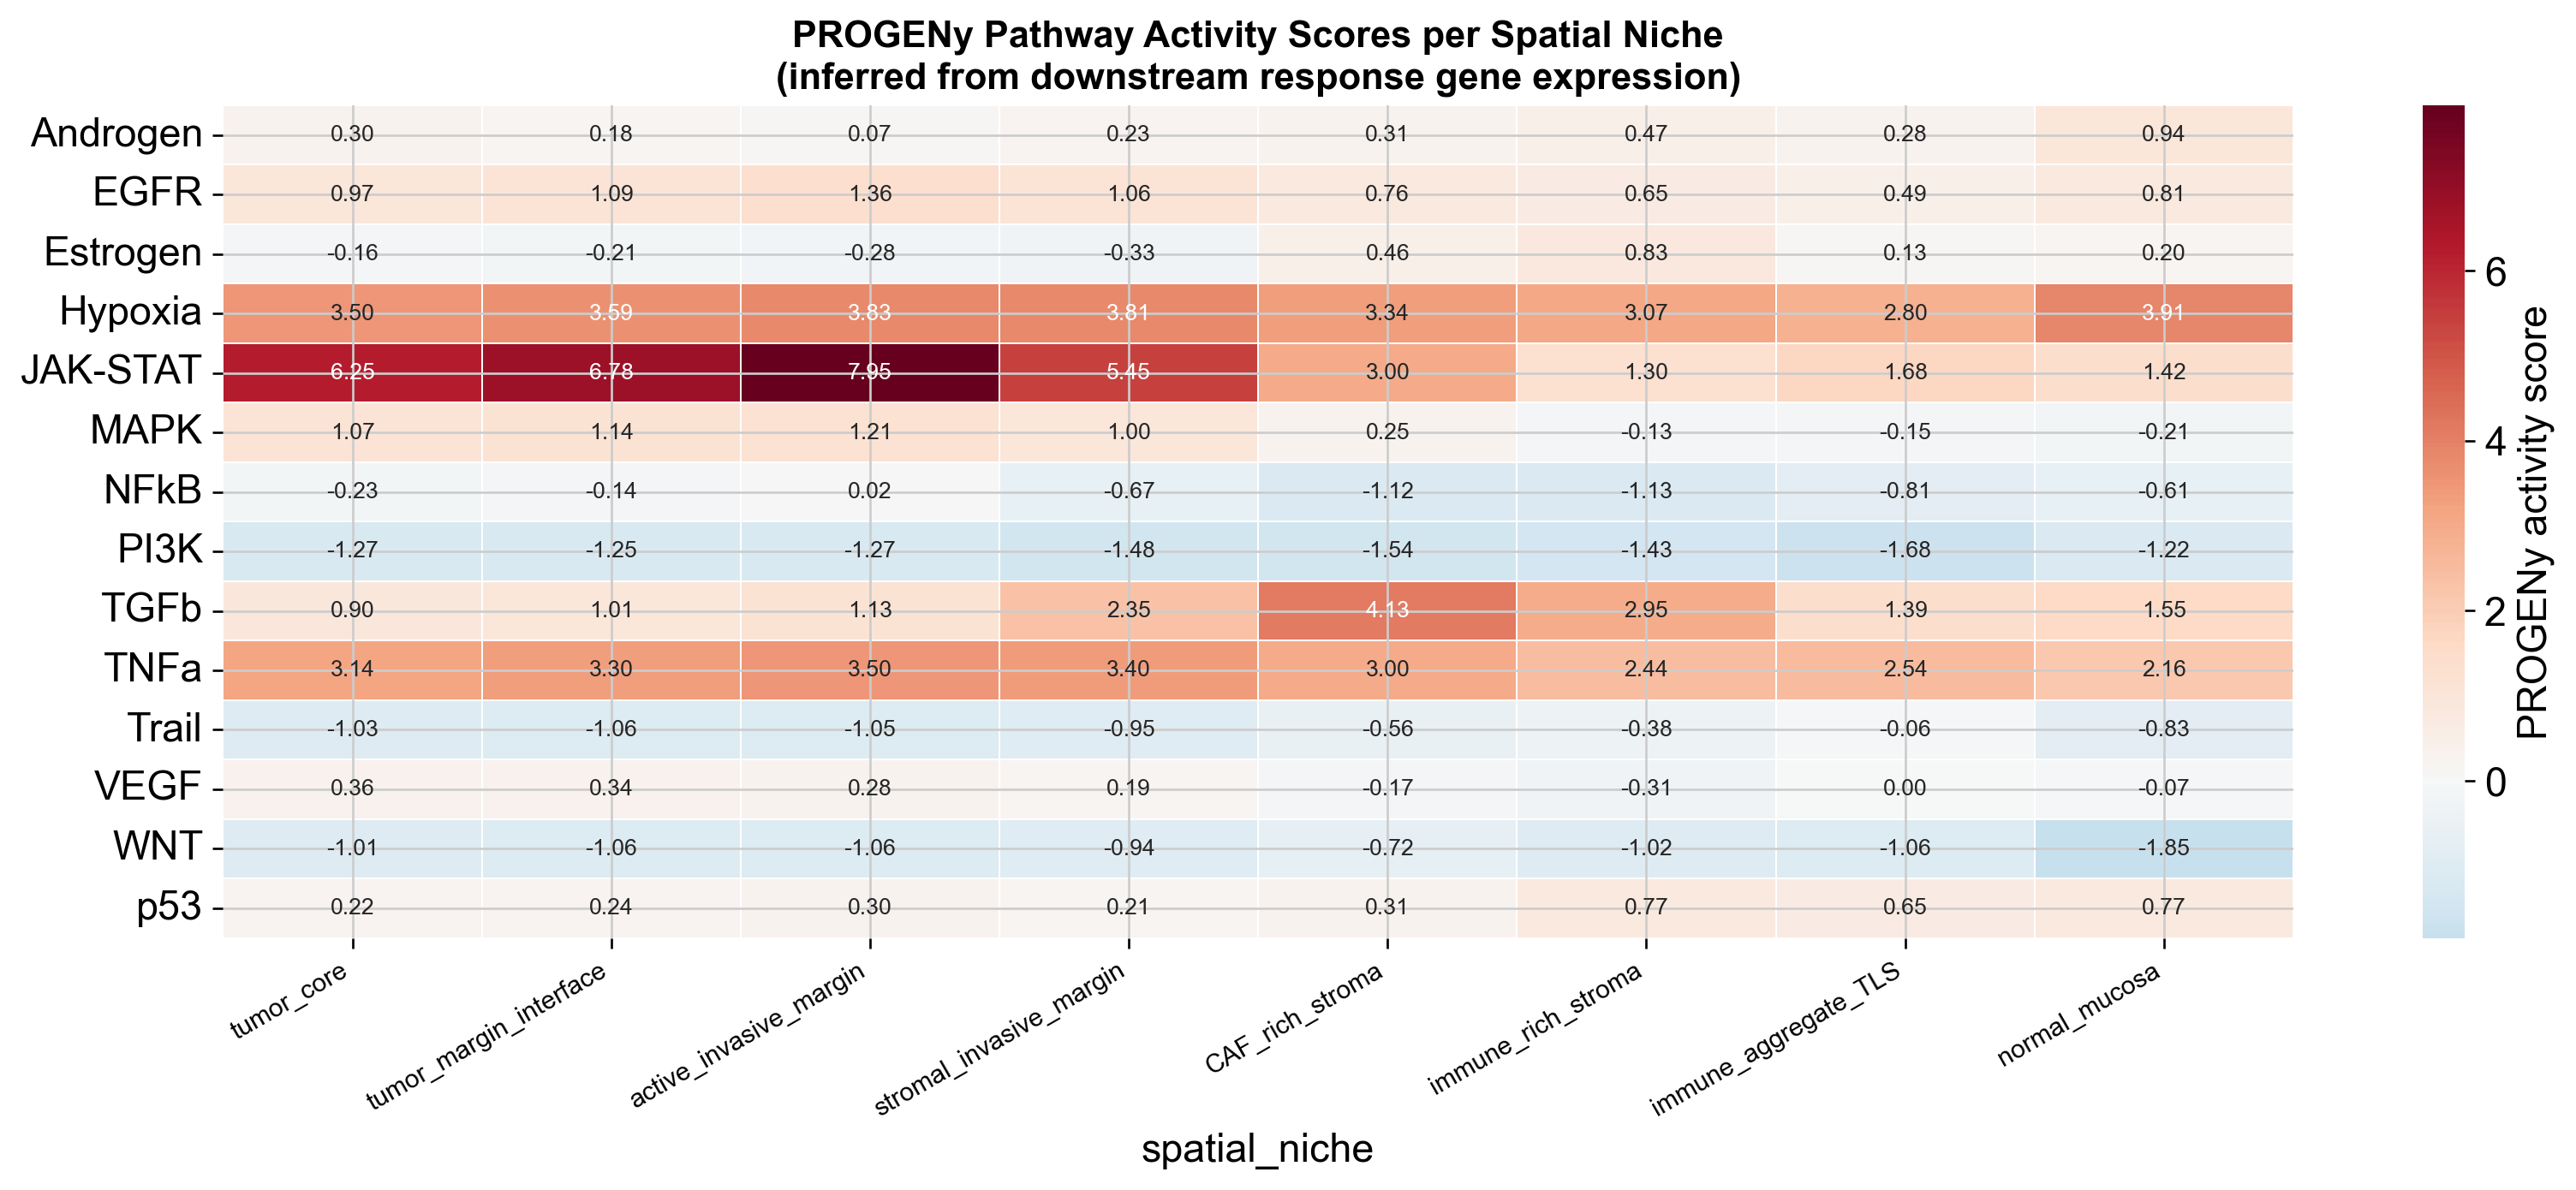

Figure saved: SV03_progeny_heatmap.png

Key patterns:
  TGFb:     highest at CAF_rich_stroma (exclusion source)
  JAK-STAT: highest at boundary niches (active cytokine conflict)
  Hypoxia:  uniformly elevated - background TME condition, not exclusion driver


In [36]:
# ── PROGENy heatmap ───────────────────────────────────────────────────────
niche_order = [
    'tumor_core','tumor_margin_interface','active_invasive_margin',
    'stromal_invasive_margin','CAF_rich_stroma','immune_rich_stroma',
    'immune_aggregate_TLS','normal_mucosa'
]
plot_df = niche_progeny.reindex([n for n in niche_order if n in niche_progeny.index])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    plot_df.T, cmap='RdBu_r', center=0, ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label':'PROGENy activity score'},
    annot=True, fmt='.2f', annot_kws={'size':8},
)
ax.set_title('PROGENy Pathway Activity Scores per Spatial Niche\n'
             '(inferred from downstream response gene expression)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'SV03_progeny_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: SV03_progeny_heatmap.png")
print("\nKey patterns:")
print("  TGFb:     highest at CAF_rich_stroma (exclusion source)")
print("  JAK-STAT: highest at boundary niches (active cytokine conflict)")
print("  Hypoxia:  uniformly elevated - background TME condition, not exclusion driver")

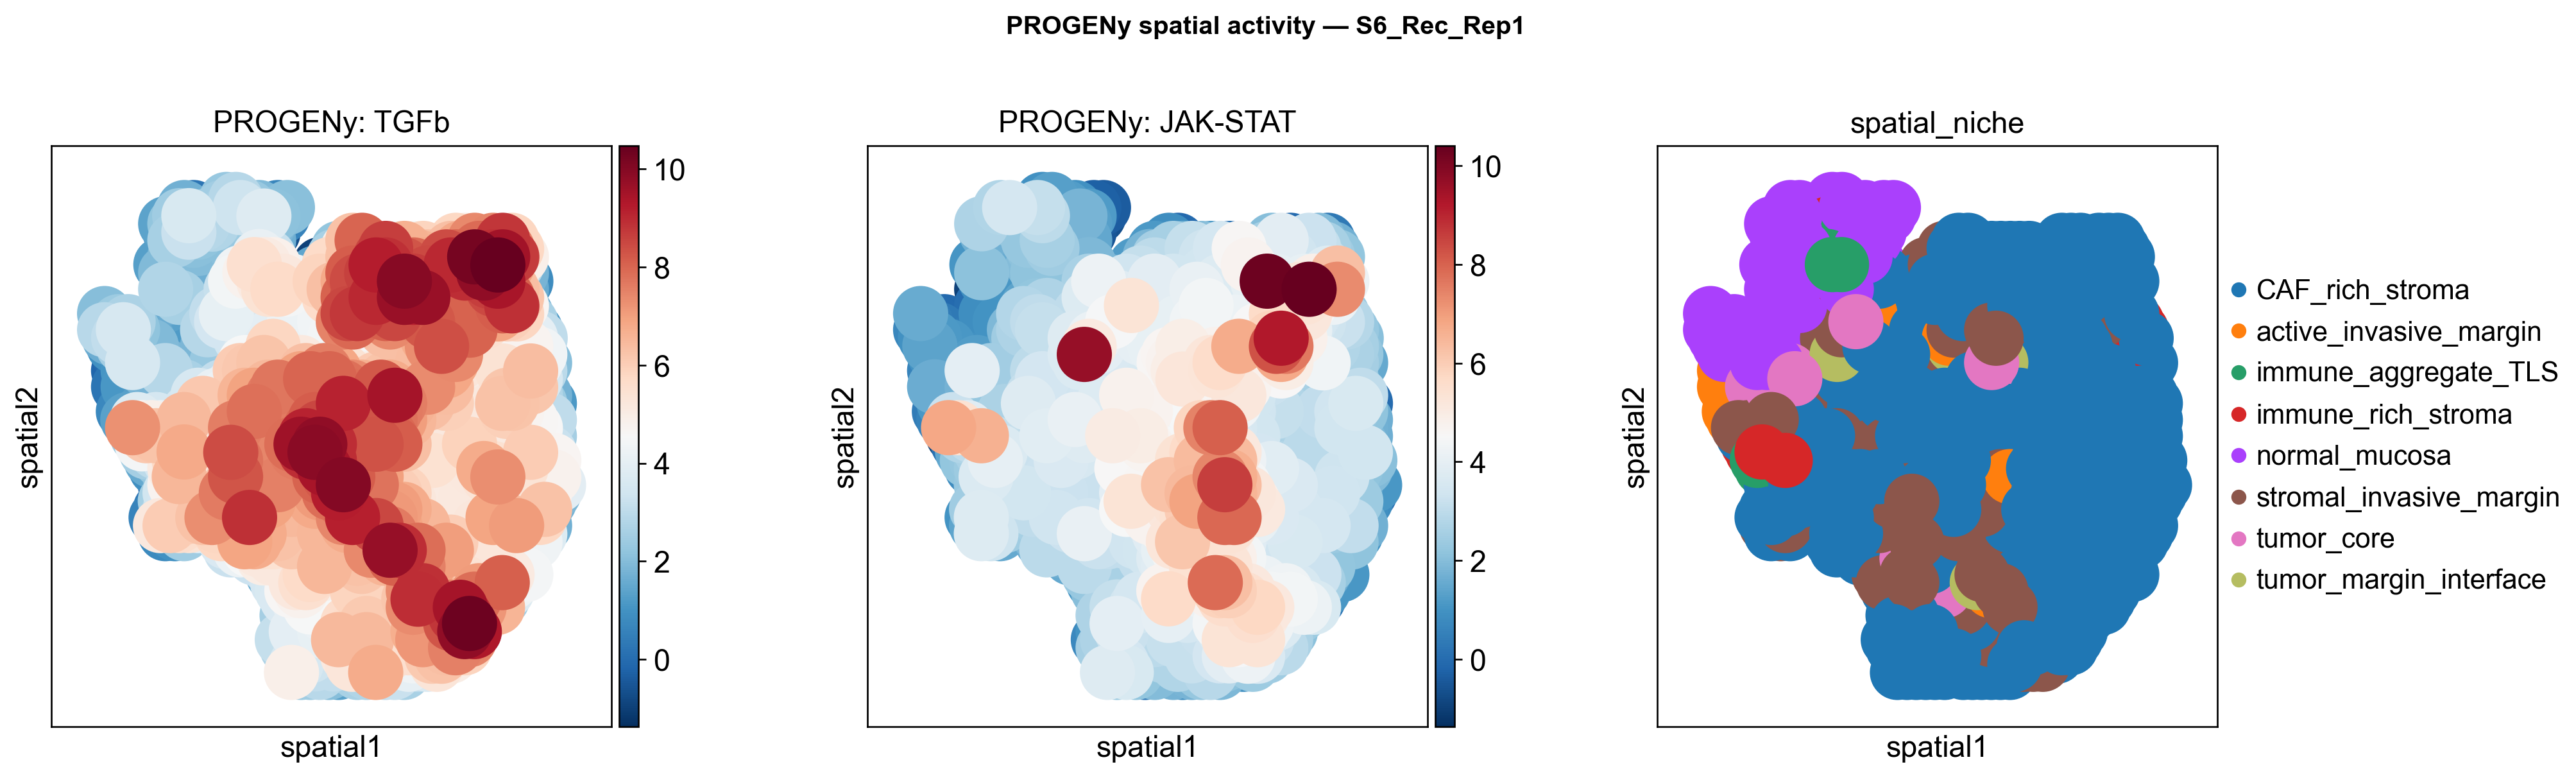

Figure saved: SV03_progeny_spatial_S6_Rec_Rep1.png


In [37]:
# ── PROGENy spatial map for representative sample ────────────────────────
EXAMPLE_SAMPLE = 'S6_Rec_Rep1'
adata_sample = adata[adata.obs['sample_id'] == EXAMPLE_SAMPLE].copy()

# Recover spatial coordinates from adata.obsm (already offset)
sample_mask = adata.obs['sample_id'] == EXAMPLE_SAMPLE
coords = pd.DataFrame(
    adata.obsm['spatial'][sample_mask],
    index=adata.obs_names[sample_mask], columns=['x','y']
)
adata_sample.obsm['spatial'] = coords.reindex(adata_sample.obs_names).values

# Find pathway columns
tgfb_col  = next((c for c in adata_sample.obs.columns
                  if c.startswith('progeny_') and 'tgf' in c.lower()), None)
jakst_col = next((c for c in adata_sample.obs.columns
                  if c.startswith('progeny_') and 'jak' in c.lower()), None)

cols = [c for c in [tgfb_col, jakst_col, 'spatial_niche'] if c]
if cols:
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for i, col in enumerate(cols):
        sc.pl.spatial(
            adata_sample, color=col, ax=axes[i], show=False,
            spot_size=150, img_key=None,
            cmap='RdBu_r' if 'progeny' in col else None,
            title=col.replace('progeny_','PROGENy: '),
        )
    plt.suptitle(f'PROGENy spatial activity — {EXAMPLE_SAMPLE}',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'SV03_progeny_spatial_{EXAMPLE_SAMPLE}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: SV03_progeny_spatial_{EXAMPLE_SAMPLE}.png")

## 5. Immune Exclusion Boundary Signature Gene Set

The boundary signature compiles genes specifically upregulated at the exclusion
boundary niches. This gene set serves as the SHAP validation target in SV06:
if XGBoost independently recovers genes from this set as top predictors of
immune phenotype without pre-selection, that validates the exclusion mechanism
computationally across the full transcriptomic feature space.

**Finding:** The boundary signature is dominated by interferon response genes,
chemokines, and IDO1 NOT by canonical CAF markers (TGFB1, ACTA2, COL1A1).
This reflects that the boundary itself is an active immune conflict zone,
while CAF-derived TGF-β signals originate from the adjacent stroma
(confirmed by PROGENy: CAF_rich_stroma TGFb score = 4.13).

In [38]:
# ── Compile boundary signature ────────────────────────────────────────────
boundary_sig_genes = set()
for niche in ['active_invasive_margin','tumor_margin_interface']:
    try:
        markers = sc.get.rank_genes_groups_df(
            adata, group=niche, key='niche_markers',
            pval_cutoff=0.05, log2fc_min=0.5,
        )
        boundary_sig_genes.update(
            markers[markers['logfoldchanges']>0]['names'].tolist()[:100]
        )
    except Exception as e:
        print(f"  {niche}: {e}")

boundary_sig_genes = sorted(boundary_sig_genes)
print(f"✓ Boundary exclusion signature: {len(boundary_sig_genes)} genes")

# Check overlap with canonical exclusion genes
known_exclusion = [
    'TGFB1','TGFB2','ACTA2','FAP','COL1A1','COL3A1','FN1','POSTN',
    'CXCL12','PDCD1LG2','MMP2','MMP9','LOXL2',
]
overlap = [g for g in known_exclusion if g in boundary_sig_genes]
print(f"\nOverlap with canonical CAF/ECM exclusion genes: "
      f"{len(overlap)}/{len(known_exclusion)}")
print(f"  Present: {overlap if overlap else 'none'}")
print(f"  Not significant at boundary: "
      f"{[g for g in known_exclusion if g not in boundary_sig_genes]}")

# Highlight what IS in the signature
ido1_present = 'IDO1' in boundary_sig_genes
ifn_genes = [g for g in boundary_sig_genes if any(
    x in g for x in ['IFI','ISG','MX','IFIT','OAS','IRF','STAT']
)]
cxcl_genes = [g for g in boundary_sig_genes
              if g.startswith('CXCL') or g.startswith('CCL')]

print(f"\nWhat IS in the boundary signature:")
print(f"  IDO1 (tryptophan depletion): {ido1_present}")
print(f"  Interferon response genes ({len(ifn_genes)}): {ifn_genes[:8]}")
print(f"  Chemokines ({len(cxcl_genes)}): {cxcl_genes}")

# Save
sig_df = pd.DataFrame({
    'gene': boundary_sig_genes,
    'in_canonical_exclusion': [g in known_exclusion for g in boundary_sig_genes],
})
sig_df.to_csv(PROCESSED_DIR/'SV03_boundary_exclusion_signature.csv', index=False)
print(f"\n✓ Saved: SV03_boundary_exclusion_signature.csv ({len(sig_df)} genes)")
print(f"  Used in SV06 to validate SHAP feature recovery")

✓ Boundary exclusion signature: 156 genes

Overlap with canonical CAF/ECM exclusion genes: 0/13
  Present: none
  Not significant at boundary: ['TGFB1', 'TGFB2', 'ACTA2', 'FAP', 'COL1A1', 'COL3A1', 'FN1', 'POSTN', 'CXCL12', 'PDCD1LG2', 'MMP2', 'MMP9', 'LOXL2']

What IS in the boundary signature:
  IDO1 (tryptophan depletion): True
  Interferon response genes (11): ['IFI27', 'IFI44', 'IFI6', 'IFIT3', 'IFITM3', 'IRF1', 'ISG15', 'MX1']
  Chemokines (9): ['CCL5', 'CXCL1', 'CXCL10', 'CXCL11', 'CXCL2', 'CXCL3', 'CXCL5', 'CXCL8', 'CXCL9']

✓ Saved: SV03_boundary_exclusion_signature.csv (156 genes)
  Used in SV06 to validate SHAP feature recovery


## 6. Save Outputs

**New additions in SV03:**
- `adata.obs['progeny_*']` - 14 PROGENy pathway activity scores per spot
- `adata.uns['niche_markers']` - Wilcoxon DE results for all 8 niches
- `SV03_boundary_exclusion_signature.csv` - SHAP validation target for SV06

In [39]:
# ── Pre-save checklist ────────────────────────────────────────────────────
print("Pre-save checklist:")
print(f"  Shape:            {adata.shape}")
print(f"  spatial_niche:    {adata.obs['spatial_niche'].nunique()} categories")
print(f"  PROGENy scores:   "
      f"{sum(1 for c in adata.obs.columns if c.startswith('progeny_'))} pathways")
print(f"  niche_markers:    {'niche_markers' in adata.uns}")
print(f"  moranI:           {'moranI' in adata.uns}")
print(f"  boundary sig:     "
      f"{(PROCESSED_DIR/'SV03_boundary_exclusion_signature.csv').exists()}")
print(f"  None layer:       {None in adata.layers}  (should be False)")

# ── Compress and save ─────────────────────────────────────────────────────
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)
for layer in list(adata.layers.keys()):
    if not sp.issparse(adata.layers[layer]):
        adata.layers[layer] = sp.csr_matrix(adata.layers[layer])

output_path = PROCESSED_DIR / 'SV03_adata_svgs.h5ad'
adata.write_h5ad(output_path, compression='gzip')
size_mb = output_path.stat().st_size / 1e6
print(f"\n✓ Saved: {output_path}")
print(f"  Size: {size_mb:.1f} MB")

Pre-save checklist:
  Shape:            (19432, 22431)
  spatial_niche:    8 categories
  PROGENy scores:   14 pathways
  niche_markers:    True
  moranI:           True
  boundary sig:     True
  None layer:       True  (should be False)

✓ Saved: ..\data\processed\SV03_adata_svgs.h5ad
  Size: 514.6 MB


## 7. Biological Interpretation & Hypotheses

### Finding 1 - IDO1 as Top Globally Spatially Variable Gene

IDO1 (Moran's I = 0.929, rank 1/3,014) emerged as the most spatially
organized gene in the entire dataset without prior selection. IDO1
catalyzes tryptophan catabolism, depleting local tryptophan and producing
kynurenine, creating a metabolically hostile microenvironment that
suppresses T cell proliferation and survival.

High Moran's I for CXCL10 (rank 9, I=0.875) and CXCL11 (rank 8, I=0.877)
alongside IDO1 reveals a molecular trap: IFN-γ-induced chemokines recruit
T cells to specific zones, while IDO1-mediated metabolic suppression prevents
their function at those exact locations. This chemokine-IDO1 spatial coupling
is an unbiased finding that will be tested in SV05 (IDO1 as a node in
tryptophan metabolism interactions) and SV06 (SHAP recovery of IDO1 as
a top predictive feature).

**Note on Moran's I coordinates:** These results used corrected per-sample
offset coordinates and supersede the Moran's I values reported in SV02,
which were computed on overlapping coordinates. COL1A1 (rank 28, I=0.818)
and ACTA2 (rank 132, I=0.636) rank highly in this corrected analysis,
confirming that ECM and CAF programs are genuinely spatially organized,
consistent with fibrotic barrier biology.

### Finding 2 - Boundary Signature Reveals Active Immune Conflict Zone

The boundary signature (genes upregulated at `active_invasive_margin` and
`tumor_margin_interface`) is dominated by:
- Interferon response genes (IFI27, ISG15, MX1, STAT1, IRF1)
- Chemokines (CXCL9, CXCL10, CXCL11, CCL5)
- Antigen presentation (HLA-C, TAP1, PSMB8/9)
- IDO1 (metabolic immune suppression)

Canonical CAF exclusion markers (TGFB1, ACTA2, COL1A1) are NOT enriched
at the boundary vs all other niches because they are broadly elevated
across the dominant stromal compartment.

This indicates the invasive margin is an **active immune conflict zone**,
not a passive fibrotic barrier. T cells are producing IFN-γ (interferon
response), tumor cells are upregulating antigen presentation and
proliferating, and IDO1 is metabolically suppressing T cell function.

### Finding 3 - PROGENy Confirms Stroma-Derived TGF-β Exclusion

TGF-β pathway activity was highest in `CAF_rich_stroma` (score = 4.13) and
lowest in `tumor_core` (score = 0.90) directly confirming that TGF-β
exclusion originates from the stromal compartment, not from cancer cells.

JAK-STAT activity was highest at boundary niches (`active_invasive_margin`
score = 7.95, `tumor_margin_interface` = 6.78) consistent with active
cytokine conflict at the tumor-immune interface (IFN-γ from T cells,
IL-6/oncostatin-M resistance signaling from stroma).

Hypoxia was uniformly elevated across all niches — a background TME
condition, not a driver of spatial exclusion architecture.

### Revised Mechanistic Model

The spatial data supports a **two-layer immune exclusion mechanism:**

**Layer 1 (stroma):** CAF-derived TGF-β (PROGENy TGFb = 4.13 in CAF_rich_stroma)
establishes the exclusion gradient emanating from the stromal compartment.

**Layer 2 (boundary):** IDO1-mediated tryptophan depletion and interferon-driven
immune suppression maintain the exclusion state at the actual tumor-immune
interface, functionally disarming T cells that arrive at the boundary.

### Testable Hypotheses for SV05 and SV06

> **SV05 prediction:** LIANA will identify TGFB1→TGFBR1/TGFBR2 as a top
> consensus ligand-receptor pair from CAF-rich spots to T cell-containing spots.
> IDO1-related tryptophan metabolism interactions (IDO1→WARS, IDO1→AHR)
> should appear as boundary-specific interactions.

> **SV06 prediction:** SHAP analysis of an XGBoost classifier predicting
> immune phenotype (excluded vs. infiltrated) will independently recover
> IDO1, CXCL10, STAT1, and ISG15 from the boundary signature and
> TGFB1, ACTA2, COL1A1 from the stromal exclusion program without
> pre-selecting these genes.

---

**Next notebook:** SV04 - Cell Type Deconvolution (Cell2Location)

SV04 deconvolves each Visium spot into estimated cell type fractions using
the Oliveira et al. 2025 FFPE scRNA-seq reference. Validation targets:
- `CAF_rich_stroma` → high CAF fraction
- `immune_aggregate_TLS` → high T cell and B cell fractions
- `tumor_core` → high malignant cell fraction
- CAF spatial distribution should correlate with TGFB1 expression and
  PROGENy TGFb scores confirmed in this notebook